In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Tahap 1: Pengumpulan Data
df = pd.read_csv('data.csv')
print("=== Tahap 1: Data Awal ===")
display(df)

# Tahap 2: Pra-pemrosesan Data
# Pemisahan fitur (6 kolom numerik)
X = df[['Bekerja_L', 'Bekerja_P', 'Bekerja_Total', 'Pengangguran_L', 'Pengangguran_P', 'Pengangguran_Total']]

# Normalisasi menggunakan Min-Max Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== Tahap 2: Data Setelah Min-Max Scaling ===")
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.insert(0, 'Pendidikan', df['Pendidikan'])
display(df_scaled)

=== Tahap 1: Data Awal ===


,Pendidikan,Bekerja_L,Bekerja_P,Bekerja_Total,Pengangguran_L,Pengangguran_P,Pengangguran_Total
0,Tidak/Belum Tamat SD,13176,9356,22532,133,0,133
1,SLTP,13684,7181,20865,163,0,163
2,SLTA,27787,20227,48014,2638,1067,3705
3,SMK,16605,6811,23416,1368,558,1926
4,Diploma I/II/III,1515,2754,4269,412,206,618
5,Diploma IV/Univ,9748,13819,23567,1173,375,1548



=== Tahap 2: Data Setelah Min-Max Scaling ===


,Pendidikan,Bekerja_L,Bekerja_P,Bekerja_Total,Pengangguran_L,Pengangguran_P,Pengangguran_Total
0,Tidak/Belum Tamat SD,0.443857,0.377840,0.417488,0.000000,0.000000,0.000000
1,SLTP,0.463193,0.253362,0.379381,0.011976,0.000000,0.008399
2,SLTA,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,SMK,0.574376,0.232187,0.437696,0.493014,0.522962,0.501960
4,Diploma I/II/III,0.000000,0.000000,0.000000,0.111377,0.193065,0.135778
5,Diploma IV/Univ,0.313375,0.633263,0.441148,0.415170,0.351453,0.396137


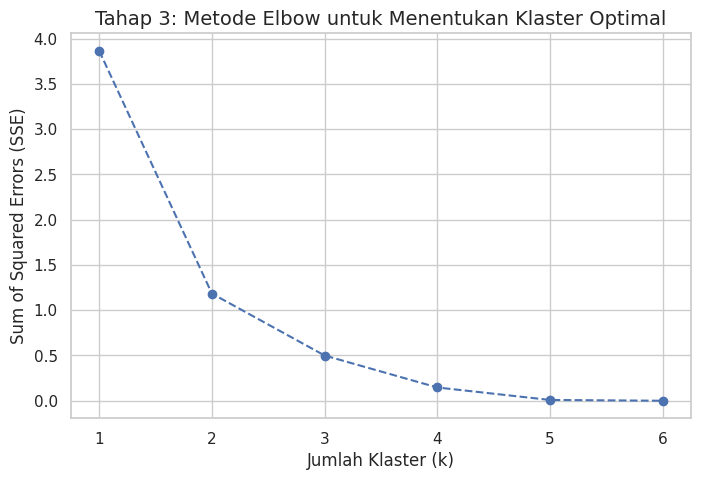

In [ ]:
# Tahap 3: Metode Elbow (k=1 hingga k=6)
sse = []
K_range = range(1, 7)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    kmeans_temp.fit(X_scaled)
    sse.append(kmeans_temp.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o', linestyle='--', color='b')
plt.title('Tahap 3: Metode Elbow untuk Menentukan Klaster Optimal', fontsize=14)
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Dari grafik Elbow, asumsikan titik patahan (elbow) terbaik berada di k=3
k_optimal = 3

In [ ]:
# Tahap 4: Implementasi K-Means dengan inisialisasi random
kmeans = KMeans(n_clusters=k_optimal, init='random', n_init=10, max_iter=300, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Tahap 5: Evaluasi dengan Silhouette Coefficient
sil_score = silhouette_score(X_scaled, df['Cluster'])

print(f"=== Tahap 5: Evaluasi Klaster ===")
print(f"Silhouette Coefficient untuk k={k_optimal} adalah: {sil_score:.4f}")
print("(Mendekati 1 berarti pengelompokan sangat baik)")

=== Tahap 5: Evaluasi Klaster ===
Silhouette Coefficient untuk k=3 adalah: 0.3289
(Mendekati 1 berarti pengelompokan sangat baik)



=== Tahap 6: Tabel Profil Hasil Klaster ===


,Pendidikan,Cluster
2,SLTA,0
3,SMK,1
5,Diploma IV/Univ,1
1,SLTP,2
0,Tidak/Belum Tamat SD,2
4,Diploma I/II/III,2


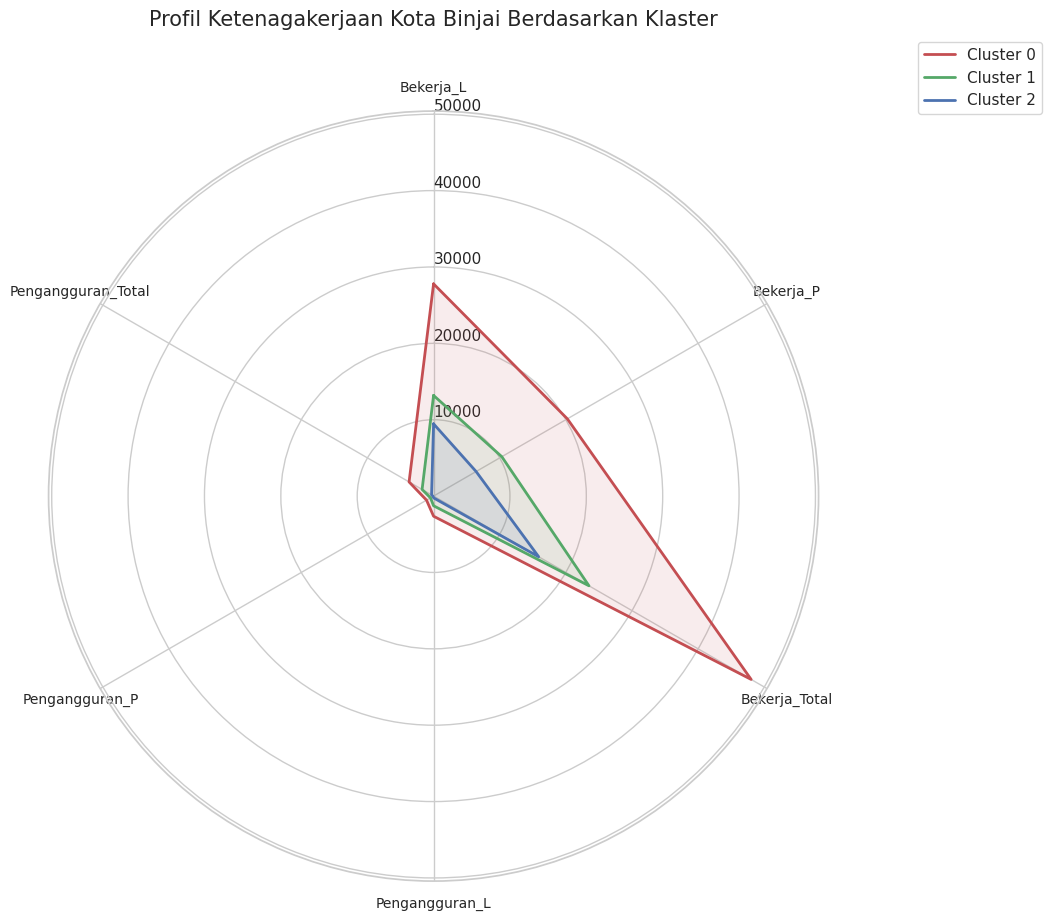

In [ ]:
# Tahap 6: Tabel Profil Klaster
print("\n=== Tahap 6: Tabel Profil Hasil Klaster ===")
display(df[['Pendidikan', 'Cluster']].sort_values(by='Cluster'))

# Persiapan data untuk Radar Chart (menggunakan rata-rata nilai per klaster)
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
df_centers = pd.DataFrame(cluster_centers, columns=X.columns)
df_centers['Cluster'] = [f"Cluster {i}" for i in range(k_optimal)]

# Visualisasi Radar Chart
categories = list(X.columns)
N = len(categories)

# Menentukan sudut untuk setiap kategori di radar chart
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10)
ax.set_rlabel_position(0)

# Warna untuk masing-masing klaster
colors = ['r', 'g', 'b']

for i in range(k_optimal):
    values = df_centers.loc[i].drop('Cluster').values.flatten().tolist()
    values += values[:1] # Tutup poligon
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=df_centers['Cluster'][i], color=colors[i])
    ax.fill(angles, values, colors[i], alpha=0.1)

plt.title('Profil Ketenagakerjaan Kota Binjai Berdasarkan Klaster', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()